# Toma de decisiones de negocios con datos

## Contexto y descripción del proyecto

En este proyecto, se trabajan con los datos de una gran tienda online, se ha recopilado una lista de hipótesis, con el objetivo de ayudar a aumentar los ingresos.

## Priorizar hipótesis

En el archivo hay 9 hipótesis sobre como aumentar los ingresos de la tienda, en estos están incluidos los parámetros Reach, Impact, Confidence y Effort.

Se ejecutará primero el archivo 'hypotheses', en la que se visualizará las columnas y la información general del DataFrame, y se comenzará primero con el framework ICE para priorizar problemas

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.stats.proportion import proportions_ztest
from datetime import timedelta

In [2]:
hypo = pd.read_csv('/datasets/hypotheses_us.csv', sep=';')


print("Columnas disponibles:")
print(hypo.columns.tolist())
print("\nPrimeras filas:")
print(hypo.head())


Columnas disponibles:
['Hypothesis', 'Reach', 'Impact', 'Confidence', 'Effort']

Primeras filas:
                                          Hypothesis  Reach  Impact  \
0  Add two new channels for attracting traffic. T...      3      10   
1  Launch your own delivery service. This will sh...      2       5   
2  Add product recommendation blocks to the store...      8       3   
3  Change the category structure. This will incre...      8       3   
4  Change the background color on the main page. ...      3       1   

   Confidence  Effort  
0           8       6  
1           4      10  
2           7       3  
3           3       8  
4           1       1  


In [3]:
hypo['ICE'] = (hypo['Impact'] * hypo['Confidence'])/hypo['Effort']

print(hypo[['Hypothesis', 'ICE']].sort_values(by='ICE', ascending=False))

                                          Hypothesis        ICE
8  Launch a promotion that gives users discounts ...  16.200000
0  Add two new channels for attracting traffic. T...  13.333333
7  Add a subscription form to all the main pages....  11.200000
6  Show banners with current offers and sales on ...   8.000000
2  Add product recommendation blocks to the store...   7.000000
1  Launch your own delivery service. This will sh...   2.000000
5  Add a customer review page. This will increase...   1.333333
3  Change the category structure. This will incre...   1.125000
4  Change the background color on the main page. ...   1.000000


También se ejecutó el Framework RICE en la cual se le añade el alcance de los usuarios

In [4]:
hypo['RICE'] = (hypo['Reach'] * hypo['Impact'] * hypo['Confidence'])/hypo['Effort']

print(hypo[['Hypothesis', 'RICE']].sort_values(by='RICE', ascending=False))

                                          Hypothesis   RICE
7  Add a subscription form to all the main pages....  112.0
2  Add product recommendation blocks to the store...   56.0
0  Add two new channels for attracting traffic. T...   40.0
6  Show banners with current offers and sales on ...   40.0
8  Launch a promotion that gives users discounts ...   16.2
3  Change the category structure. This will incre...    9.0
1  Launch your own delivery service. This will sh...    4.0
5  Add a customer review page. This will increase...    4.0
4  Change the background color on the main page. ...    3.0


Haciendo una comparación de ambos, se muestran algunas caracteristicas importantes:

**Top 3 con ICE:**
1. Launch a promotion (16.2) - Era #1
2. Add two new channels (13.3) - Era #2  
3. Add subscription form (11.2) - Era #3

**Top 3 con RICE:**
1. Add subscription form (112.0) - ¡Subió de #3 a #1!
2. Add product recommendation (56.0) - ¡Subió de #5 a #2!
3. Add two new channels (40.0) - Bajó de #2 a #3

## Cambios significativos

Al comparar ambas fórmulas se llegaron a las siguientes conclusiones:

"Add subscription form" se convirtió en #1 porque:
*   Tiene un Reach alto (muchos usuarios lo verán)
*   Cuando multiplicas por Reach, su puntaje se dispara

"Launch a promotion" bajó dramáticamente porque:
*   Tiene Reach bajo (pocos usuarios afectados)
*   A pesar de tener buen "Impact" y "Confidence", el bajo "Reach" lo penaliza

**En resumen:** ICE se enfoca en la eficiencia (impacto por esfuerzo), mientras que RICE considera también la escala (cuántos usuarios se benefician)

## Análisis del test A/B

Una vez analizada las diferencias de la hipótesis, ahora se realizará una prueba A/B de acuerdo con las órdenes y visitas de la tienda.

Se hizo un gráfico que muestra los ingresos acumulados por grupo.

In [5]:
orders = pd.read_csv('/datasets/orders_us.csv', sep=',')
visits = pd.read_csv('/datasets/visits_us.csv', sep=',')

In [6]:
print("Columnas disponibles:")
print(orders.columns.tolist())
print("\nPrimeras filas:")
print(orders.head())

Columnas disponibles:
['transactionId', 'visitorId', 'date', 'revenue', 'group']

Primeras filas:
   transactionId   visitorId        date  revenue group
0     3667963787  3312258926  2019-08-15     30.4     B
1     2804400009  3642806036  2019-08-15     15.2     B
2     2961555356  4069496402  2019-08-15     10.2     A
3     3797467345  1196621759  2019-08-15    155.1     B
4     2282983706  2322279887  2019-08-15     40.5     B


In [7]:
print("Columnas disponibles:")
print(visits.columns.tolist())
print("\nPrimeras filas:")
print(visits.head(10))

Columnas disponibles:
['date', 'group', 'visits']

Primeras filas:
         date group  visits
0  2019-08-01     A     719
1  2019-08-02     A     619
2  2019-08-03     A     507
3  2019-08-04     A     717
4  2019-08-05     A     756
5  2019-08-06     A     667
6  2019-08-07     A     644
7  2019-08-08     A     610
8  2019-08-09     A     617
9  2019-08-10     A     406


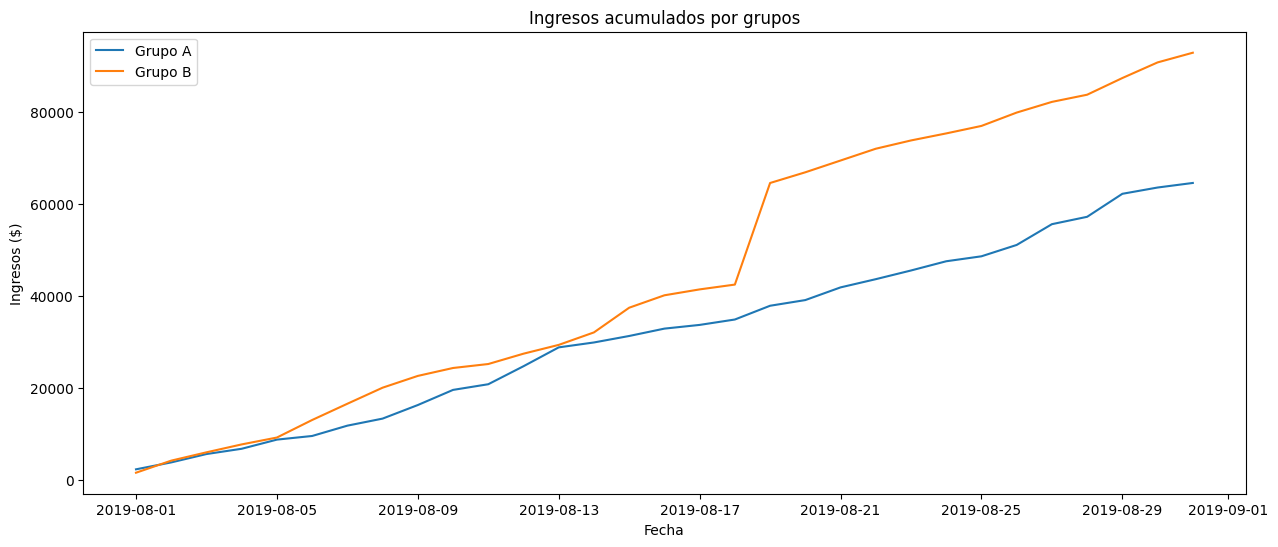

In [8]:
# 1. Convertir la columna 'date' a formato datetime
orders['date'] = pd.to_datetime(orders['date'])

# 2. Agrupar por fecha y grupo, sumar los ingresos
daily_revenue = orders.groupby(['date', 'group'])['revenue'].sum().reset_index()

# 3. Calcular el ingreso acumulado para cada grupo
daily_revenue['cumulative_revenue'] = daily_revenue.groupby('group')['revenue'].cumsum()

# seleccionar datos
cumulativeDataA = daily_revenue[daily_revenue['group']=='A'][['cumulative_revenue', 'date']]
cumulativeDataB = daily_revenue[daily_revenue['group']=='B'][['cumulative_revenue', 'date']]

# Obtener las fechas para cada grupo
datesA = daily_revenue[daily_revenue['group']=='A']['date']
datesB = daily_revenue[daily_revenue['group']=='B']['date']

# Crear el gráfico correctamente
plt.figure(figsize=(15,6))
plt.title('Ingresos acumulados por grupos')
plt.xlabel('Fecha'); plt.ylabel('Ingresos ($)')
plt.plot(datesA, cumulativeDataA['cumulative_revenue'], label='Grupo A')
plt.plot(datesB, cumulativeDataB['cumulative_revenue'], label='Grupo B')

plt.legend()
plt.show()

El Grupo B es el que genera más ingresos que el grupo A, existe cierta diferencia entre los grupos, esta se nota a partir del 5to día en las cuales, el grupo B comienza a generar más ingresos y la diferencia es más notoria a la 2da semana, que supera bastante los ingresos

### Tamaño de pedido promedio

Una vez conseguido el ingreso acumulado, ahora se calcularon los promedios de cada grupo por día 

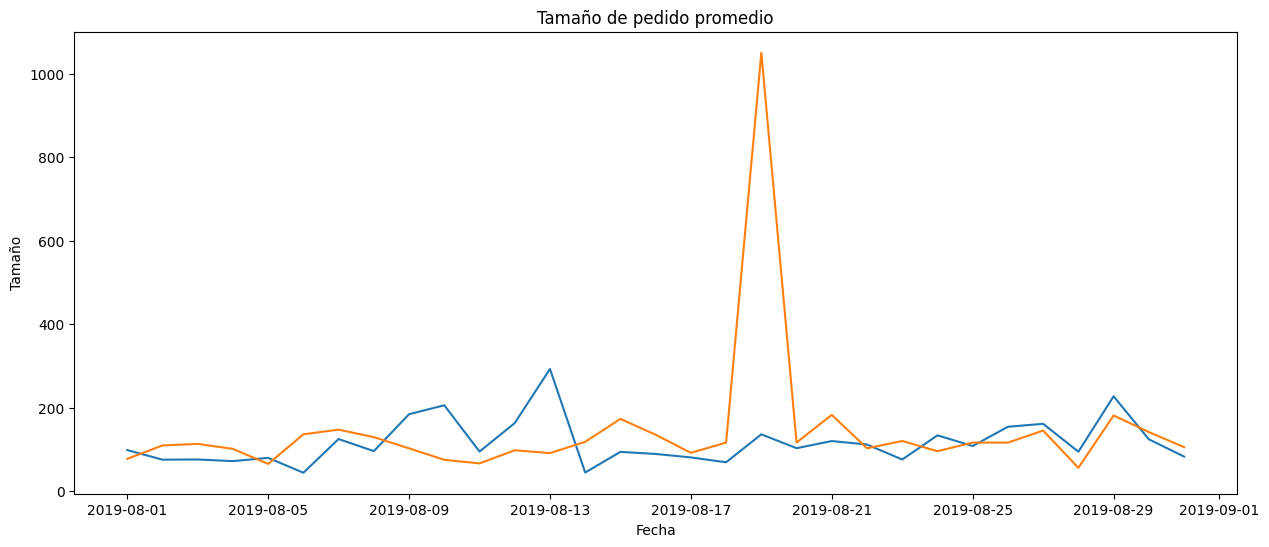

In [9]:
daily_revenue = orders.groupby(['date', 'group'])['revenue'].mean().reset_index()

MeanDataA = daily_revenue[daily_revenue['group']=='A'][['revenue', 'date']]
MeanDataB = daily_revenue[daily_revenue['group']=='B'][['revenue', 'date']]


mean_cumulative_a = MeanDataA.groupby('date')['revenue'].mean().reset_index()
mean_cumulative_b = MeanDataB.groupby('date')['revenue'].mean().reset_index()

plt.figure(figsize=(15,6))
plt.title('Tamaño de pedido promedio')
plt.xlabel('Fecha'); plt.ylabel('Tamaño')
plt.plot(mean_cumulative_a['date'], mean_cumulative_a['revenue'], label='Grupo A')
plt.plot(mean_cumulative_b['date'], mean_cumulative_b['revenue'], label='Grupo B')

El gráfico muestra el valor promedio de cada pedido. el tamaño mas alto es el del 19 de agosto del 2019, que tuvo un promedio de más de 1000, esto es un dato atípico.

### Diferencia relativa

Al obtener los promedios de cada grupo, se calculó la diferencia relativa

0    -23.060854
1     10.152162
2     17.913063
3     18.196913
4     20.015780
5     25.719272
6     37.913223
7     32.072493
8     29.759165
9     14.378557
10     4.263251
11     1.824876
12    -7.817138
13   -10.576472
14    -7.402885
15     1.242532
16     2.652884
17     3.484482
18    30.737166
19    46.549886
20    47.894698
21    44.787816
22    43.348639
23    41.776655
24    40.934726
25    39.062104
26    36.191503
27    31.986294
28    28.194886
29    25.003880
30    25.145234
Name: avg_cumulative, dtype: float64


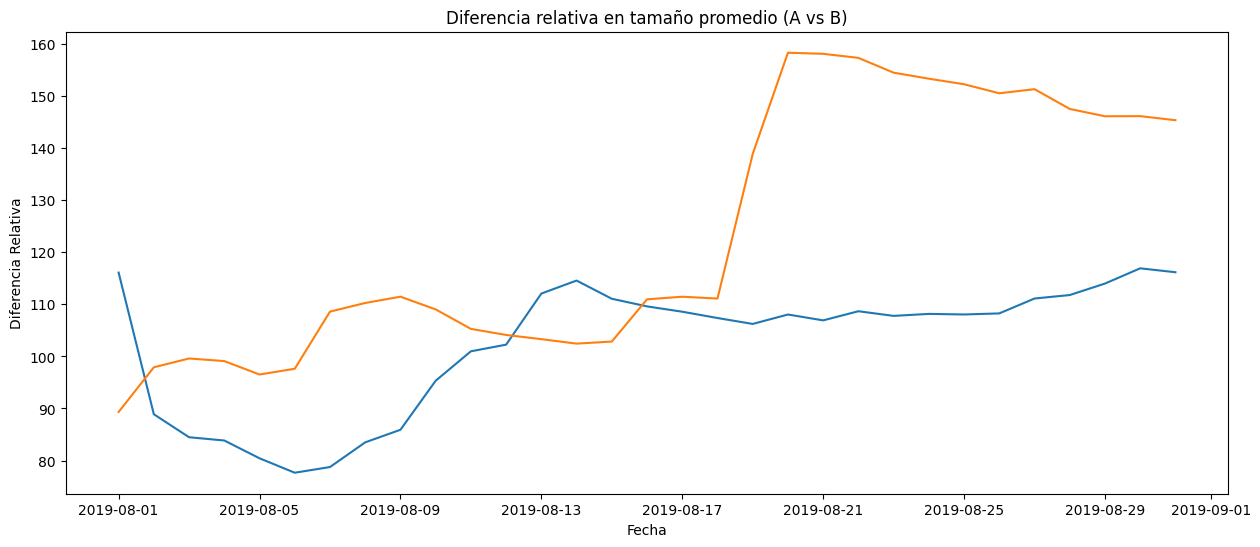

In [10]:
# 1. Ordenar por fecha
orders_sorted = orders.sort_values(['group', 'date'])

# 2. Calcular promedio acumulado para cada grupo
orders_sorted['avg_cumulative'] = orders_sorted.groupby('group')['revenue'].expanding().mean().reset_index(0, drop=True)

# 3. Separar por grupos
group_a = orders_sorted[orders_sorted['group']=='A'][['date', 'avg_cumulative']]
group_b = orders_sorted[orders_sorted['group']=='B'][['date', 'avg_cumulative']]

a_group = group_a.groupby('date')['avg_cumulative'].mean().reset_index()
b_group = group_b.groupby('date')['avg_cumulative'].mean().reset_index()

diferencia_relativa = (b_group['avg_cumulative'] - a_group['avg_cumulative']) / a_group['avg_cumulative'] * 100
print(diferencia_relativa)

plt.figure(figsize=(15,6))
plt.title('Diferencia relativa en tamaño promedio (A vs B)')
plt.xlabel('Fecha'); plt.ylabel('Diferencia Relativa')
plt.plot(a_group['date'], a_group['avg_cumulative'], label='Grupo A')
plt.plot(b_group['date'], b_group['avg_cumulative'], label='Grupo B')
plt.show()


En un inicio el grupo A tenía una gran diferencia con el grupo B, pero en 2 semanas después, el grupo B lo fúe superando con creces

### Tasa de conversión

A cada grupo se hizo una taza de conversión entre los pedidos y el número de visitas de cada día

In [11]:
# Pedidos por día y grupo

orders_per_day = orders.groupby(['group', 'date']).agg({'transactionId':'nunique'}).reset_index()
orders_per_day.rename(columns={'transactionId':'orders'}, inplace=True)

orders_per_day.head(10)

,group,date,orders
0,A,2019-08-01,24
1,A,2019-08-02,20
2,A,2019-08-03,24
3,A,2019-08-04,16
4,A,2019-08-05,25
5,A,2019-08-06,18
6,A,2019-08-07,18
7,A,2019-08-08,16
8,A,2019-08-09,16
9,A,2019-08-10,16


In [12]:
#Conversión de fecha
visits['date'] = pd.to_datetime(visits['date'])

# Unir con visits
daily = pd.merge(visits, orders_per_day, on=['group','date'], how='left').fillna(0)
daily['conversion'] = daily['orders'] / daily['visits']

daily.head(10)

,date,group,visits,orders,conversion
0,2019-08-01,A,719,24,0.033380
1,2019-08-02,A,619,20,0.032310
2,2019-08-03,A,507,24,0.047337
3,2019-08-04,A,717,16,0.022315
4,2019-08-05,A,756,25,0.033069
5,2019-08-06,A,667,18,0.026987
6,2019-08-07,A,644,18,0.027950
7,2019-08-08,A,610,16,0.026230
8,2019-08-09,A,617,16,0.025932
9,2019-08-10,A,406,16,0.039409


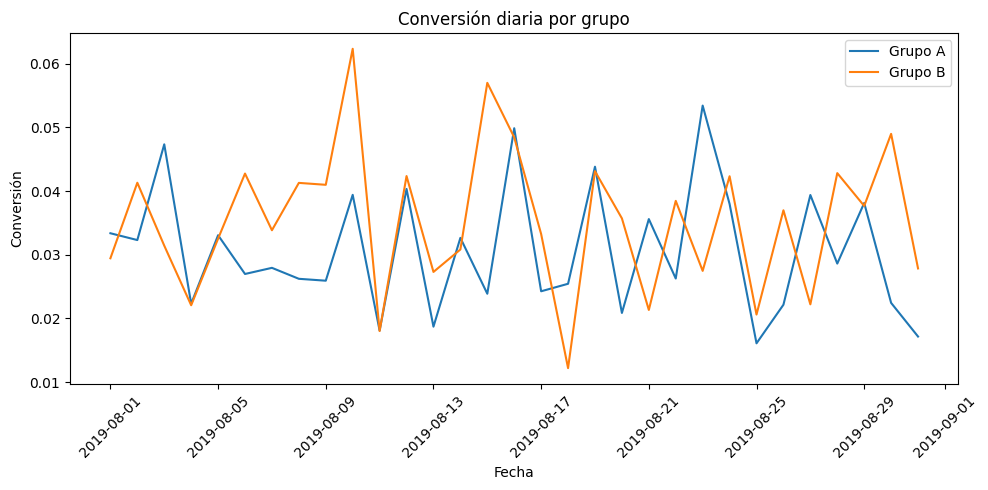

In [13]:
plt.figure(figsize=(10,5))
for grp in ['A','B']:
    grp_data = daily[daily['group']==grp]
    plt.plot(grp_data['date'], grp_data['conversion'], label=f'Grupo {grp}')
plt.title('Conversión diaria por grupo')
plt.xlabel('Fecha')
plt.ylabel('Conversión')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Las conversiones diarias difieren bastante de cada día y grupo, las mas notables son entre la 2da y 3ra semana, en algunos días, el grupo B supera al grupo A, y en otros días, el grupo A supera el grupo B

## Gráficas de dispersión y Percentiles
### Números de pedidos por usuario

Con los datos de la tasa de conversión de cada grupo, se hizo un gráfico de dispersión por el número de pedidos por usuario, para eso se visualizará la diustribución para identificar qué usuarios tienen bastantes pedidos

In [14]:
print(orders.head(15))

    transactionId   visitorId       date  revenue group
0      3667963787  3312258926 2019-08-15     30.4     B
1      2804400009  3642806036 2019-08-15     15.2     B
2      2961555356  4069496402 2019-08-15     10.2     A
3      3797467345  1196621759 2019-08-15    155.1     B
4      2282983706  2322279887 2019-08-15     40.5     B
5       182168103   935554773 2019-08-15     35.0     B
6       398296753  2900797465 2019-08-15     30.6     B
7      2626614568    78758296 2019-08-15     20.1     A
8      1576988021   295230930 2019-08-15    215.9     A
9      1506739906  1882260405 2019-08-15     30.5     B
10     3649131742   879864040 2019-08-15     65.7     A
11     1919444843   927791387 2019-08-15     70.2     B
12     2809384911  3213223594 2019-08-15    115.4     A
13     3044797713   728063420 2019-08-15    185.4     B
14     3859315276  1565034404 2019-08-15    170.9     A


In [15]:
orders_per_user = orders.groupby('visitorId').agg({'transactionId':'nunique'}).reset_index()
orders_per_user.rename(columns={'transactionId':'orders'}, inplace=True)

orders_per_user.head(15)

,visitorId,orders
0,5114589,1
1,6958315,1
2,8300375,2
3,11685486,1
4,39475350,1
5,47206413,1
6,48147722,1
7,54447517,1
8,56960363,1
9,66685450,1


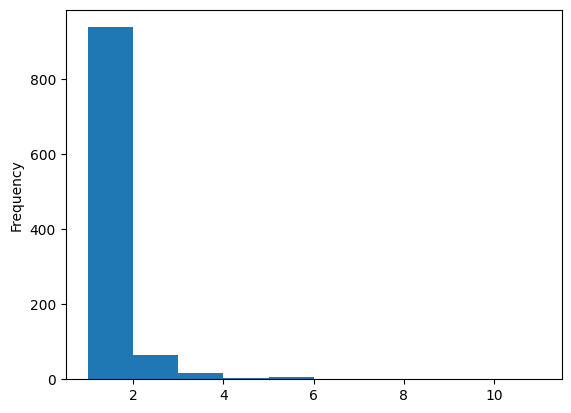

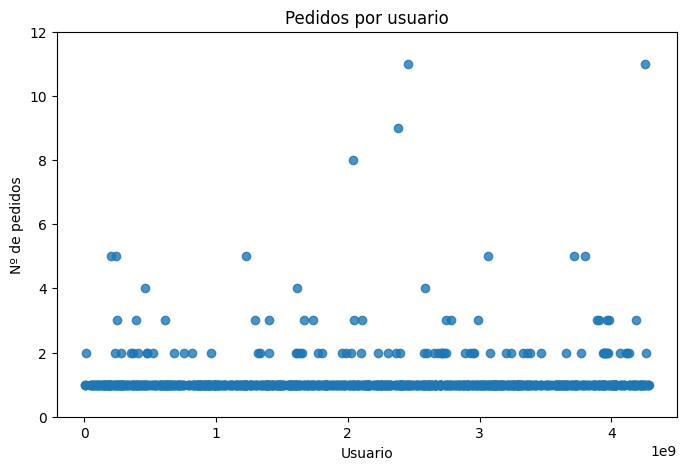

In [16]:
# Histograma de freecuencia
orders_per_user['orders'].plot(kind='hist')

# gráfico de dispersión

plt.figure(figsize=(8,5))
plt.scatter(orders_per_user['visitorId'], orders_per_user['orders'], alpha=0.8)
plt.title('Pedidos por usuario')
plt.xlabel('Usuario')
plt.ylabel('Nº de pedidos')
plt.ylim(0, orders_per_user['orders'].max()+1)
plt.show()

La gran mayoría de los usuarios piden por lo general, un pedido, unos cuantos piden más de uno, lo interesante es que una *pequeña minoría* realiza más de *2 pedidos*. Por ende, los usuarios prefieren sólo realizar un pedido

Tras analizar la cantidad de pedidos por usuario, se calcularon los percentiles, se eligieron los 95 y 99 por ser los ideales para este calculo

In [17]:
q95_orders = np.percentile(orders_per_user['orders'], 95)
q99_orders = np.percentile(orders_per_user['orders'], 99)
print(f'Percentil 95: {q95_orders}, Percentil 99: {q99_orders}')

Percentil 95: 2.0, Percentil 99: 4.0


Los valores por encima del percentil 99 son anomalías

### Precios de los pedidos.

Se examina la dispersión de precios por pedido, con el propósito de detectar el precio por la que pagan los pedidos, de esa forma identificar las posibles preferencias de usuario

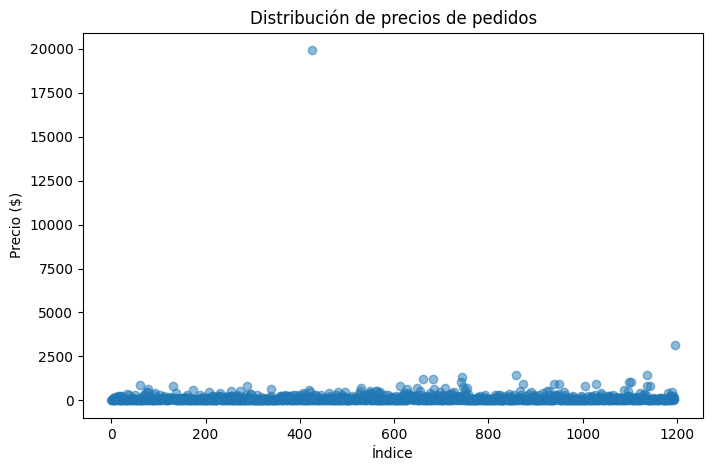

In [18]:
plt.figure(figsize=(8,5))
plt.scatter(range(len(orders)), orders['revenue'], alpha=0.5)
plt.title('Distribución de precios de pedidos')
plt.xlabel('Índice')
plt.ylabel('Precio ($)')
plt.show()

<AxesSubplot:ylabel='Frequency'>

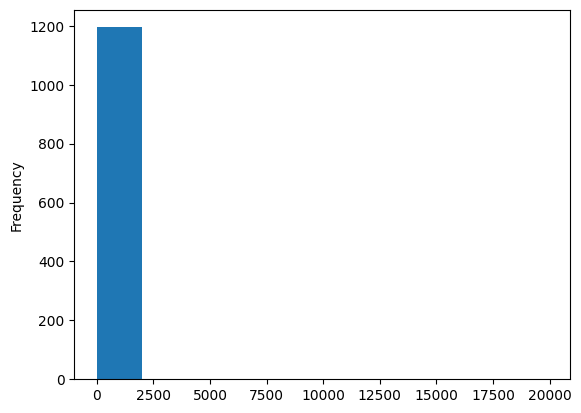

In [19]:
orders['revenue'].plot(kind='hist')

La gran mayoría de los pedidos no superan los "$" 2500, sólo una minúscula minoría lo supera

Tras analizar el precio de los pedidos por usuario, se calcularon los percentiles, se eligieron los 95 y 99 por ser los ideales para este calculo


In [20]:
q95_rev = np.percentile(orders['revenue'], 95)
q99_rev = np.percentile(orders['revenue'], 99)
print(f'Percentil 95: {q95_rev:.2f}, Percentil 99: {q99_rev:.2f}')


Percentil 95: 435.54, Percentil 99: 900.90


El umbral de anomalía de precio en el percentil 99 es de 900.90 

## Significancia estadísitica

### Conversión de grupos

Se prueba la diferencia de conversión con datos sin filtrar, con el objetivo de mostrar la primera indicación de signficancia. As como se necesitará el Total de pedidos por grupo (éxitos), el Total de visitas por grupo (intentos) y Aplicar una prueba Z para comparar proporciones, y para eso se necesitan agregar datos por grupo (sumar todos los pedidos y visitas), calcular las tasas de conversión de cada grupo, aplicar la prueba estadística (z-test para proporciones) e interpretar el p-value

In [21]:
conversions = daily.groupby('group').agg({'orders':'sum', 'visits':'sum'})
print(conversions)

       orders  visits
group                
A         557   18736
B         640   18916


In [22]:
success = conversions['orders']
print(success)

group
A    557
B    640
Name: orders, dtype: int64


In [23]:
trials = conversions['visits']
print(trials)

group
A    18736
B    18916
Name: visits, dtype: int64


In [24]:
stat, pval = proportions_ztest(success, trials)
print(f'Estadístico z: {stat:.4f}, p-valor: {pval:.4f}')

Estadístico z: -2.2700, p-valor: 0.0232


El valor p indica una diferencia significativa de 0.0232 en la conversión, se reveló que el grupo B tiene un total de 640 ordenes, lo que supera al grupo A, al igual que el total de visitas por grupo, que también lo supera


### Tamaño promedio de pedidos entre grupos

Se estudia la diferencia en el tamaño promedio de pedido (revenue) entre los grupos A y B es estadísticamente significativa o si podría haber ocurrido por casualidad. Para eso, se necesita comparar medias entre dos grupos usando una prueba t de Student (t-test). Esta prueba nos dice si las medias son significativamente diferentes. Para realizarlo se necesita, separar los datos de revenue por grupo (A y B), calcular estadísticas descriptivas (media, desviación estándar), aplicar la prueba t para muestras independientes e interpretar el p-value

In [25]:
a_revenue = orders[orders['group']=='A']['revenue']
b_revenue = orders[orders['group']=='B']['revenue']

print(a_revenue)
print(b_revenue)

2        10.2
7        20.1
8       215.9
10       65.7
12      115.4
        ...  
1187     15.5
1188      5.7
1193     50.1
1194    165.3
1195      5.5
Name: revenue, Length: 557, dtype: float64
0         30.4
1         15.2
3        155.1
4         40.5
5         35.0
         ...  
1189     490.4
1190     135.3
1191     255.7
1192     100.8
1196    3120.1
Name: revenue, Length: 640, dtype: float64


In [26]:

# Cálculo de Estadísticas descriptivas
mean_a = a_revenue.mean()
mean_b = b_revenue.mean()
std_a = a_revenue.std()
std_b = b_revenue.std()

print(f"Grupo A - Media: ${mean_a:.2f}, Desviación estándar: ${std_a:.2f}")
print(f"Grupo B - Media: ${mean_b:.2f}, Desviación estándar: ${std_b:.2f}")
print(f"Diferencia en medias: ${mean_b - mean_a:.2f}")
# Aplicar la prueba t de Student para comparar las medias de dos grupos independientes:

t_stat, p_value = stats.ttest_ind(a_revenue, b_revenue)
print(f"Estadístico t: {t_stat:.4f}")
print(f"P-valor: {p_value:.4f}")


Grupo A - Media: $115.90, Desviación estándar: $182.36
Grupo B - Media: $145.06, Desviación estándar: $806.99
Diferencia en medias: $29.17
Estadístico t: -0.8346
P-valor: 0.4041


Interpretación de los resultados:
  
*   P-valor < 0.05: Diferencia estadísticamente significativa
*   P-valor ≥ 0.05: No hay diferencia estadísticamente significativa

Los resultados muestran que no hay una diferencia significativa de cada grupo, aún así el grupo B tiene mejor rendimiento

### Diferencia en la conversión entre los grupos con los datos filtrados.

Una vez que la significancia estadística de la conversión usando datos en bruto se haya calculado, se obtuvo un p-valor de 0.0232 (estadísticamente significativo). Se hizo el mismo análisis pero con datos filtrados, removiendo las anomalías identificadas.

In [27]:
# Filtrar anomalías de revenue
orders_filtered = orders[orders['revenue'] <= q99_rev]

# Filtrar anomalías de usuarios con muchos pedidos
user_order_counts = orders_filtered.groupby('visitorId').size()
valid_users = user_order_counts[user_order_counts <= q99_orders].index
orders_filtered = orders_filtered[orders_filtered['visitorId'].isin(valid_users)]

print(f"Datos originales: {len(orders)} pedidos")
print(f"Datos filtrados: {len(orders_filtered)} pedidos")

Datos originales: 1197 pedidos
Datos filtrados: 1116 pedidos


In [28]:
# Recalculación de conversiones por grupo

# Pedidos por día y grupo (con datos filtrados)
orders_per_day_filtered = orders_filtered.groupby(['group', 'date']).agg({'transactionId':'nunique'}).reset_index()
orders_per_day_filtered.rename(columns={'transactionId':'orders'}, inplace=True)

# Unir con visits (las visitas no cambian)
daily_filtered = pd.merge(visits, orders_per_day_filtered, on=['group','date'], how='left').fillna(0)
daily_filtered['conversion'] = daily_filtered['orders'] / daily_filtered['visits']

print("Conversiones con datos filtrados:")
print(daily_filtered.head())

Conversiones con datos filtrados:
        date group  visits  orders  conversion
0 2019-08-01     A     719      23    0.031989
1 2019-08-02     A     619      20    0.032310
2 2019-08-03     A     507      24    0.047337
3 2019-08-04     A     717      13    0.018131
4 2019-08-05     A     756      25    0.033069


In [29]:
# Agrupar por grupo

conversions_filtered = daily_filtered.groupby('group').agg({'orders':'sum', 'visits':'sum'})
print("Totales con datos filtrados:")
print(conversions_filtered)

Totales con datos filtrados:
       orders  visits
group                
A         515   18736
B         601   18916


In [30]:
success_filtered = conversions_filtered['orders']
trials_filtered = conversions_filtered['visits']
print(success_filtered)
print(trials_filtered)


group
A    515
B    601
Name: orders, dtype: int64
group
A    18736
B    18916
Name: visits, dtype: int64


In [31]:
stat, pval = proportions_ztest(success_filtered, trials_filtered)
print(f'Estadístico z: {stat:.4f}, p-valor: {pval:.4f}')

Estadístico z: -2.4513, p-valor: 0.0142


In [33]:
# Cálculo de Estadísticas descriptivas
a_revenue_filtered = orders_filtered[orders_filtered['group']=='A']['revenue']
b_revenue_filtered = orders_filtered[orders_filtered['group']=='B']['revenue']

mean_a_filt = a_revenue_filtered.mean()
mean_b_filt = b_revenue_filtered.mean()
std_a_filt = a_revenue_filtered.std()
std_b_filt = b_revenue_filtered.std()

print(f"Grupo A filtrado - Media: ${mean_a_filt:.2f}, Desviación estándar: ${std_a_filt:.2f}")
print(f"Grupo B filtrado - Media: ${mean_b_filt:.2f}, Desviación estándar: ${std_b_filt:.2f}")
print(f"Diferencia en medias: ${mean_b_filt - mean_a_filt:.2f}")

# Aplicar la prueba t correctamente
t_stat, p_value = stats.ttest_ind(a_revenue_filtered, b_revenue_filtered)
print(f"Estadístico t: {t_stat:.4f}")
print(f"P-valor: {p_value:.4f}")


Grupo A filtrado - Media: $102.95, Desviación estándar: $136.78
Grupo B filtrado - Media: $101.37, Desviación estándar: $131.02
Diferencia en medias: $-1.58
Estadístico t: 0.1972
P-valor: 0.8437


Comparación con prueba anterior:

Datos sin filtrar (celda 49):
*   P-valor: 0.4041
*   Estadístico t: -0.8346
*   Diferencia en medias: $29.17 (B > A)

Datos filtrados (celda 57):
*   P-valor: 0.8437
*   Estadístico t: 0.1972
*   Diferencia en medias: -$1.58 (A > B)

Resultados:

*   Ambos p-valores son > 0.05 → No hay diferencia estadísticamente significativa en ningún caso
*   El p-valor aumentó después del filtrado (de 0.4041 a 0.8437) → La diferencia se volvió aún menos significativa
*   Sin filtrar: B > A por 29.17, Con filtrado: A > B por 1.58, por lo cual la dirección del efecto cambió

Las anomalías estaban creando una diferencia artificial entre los grupos. Al removerlas:

La diferencia real entre grupos es prácticamente cero (-$1.58), Las anomalías hacían que el grupo B pareciera tener pedidos más grandesSin las anomalías, no hay diferencia real en el tamaño promedio de pedidos

### Significancia estadística de la diferencia en el tamaño promedio de pedido entre los grupos con datos filtrados

Para el procedimiento para analizar la diferencia estadísitica del tamaño promedio con datosa filtrados se tomaron en cuenta las siguiente observaciopnes de los calculos de significancia estadistica usados anteriormente


1. Preparación de datos filtrados
Primero filtraste las anomalías:

*   Revenue > percentil 99 ($900.90): Pedidos extremadamente caros
*   Usuarios con > 4 pedidos: Usuarios con comportamiento atípico
*   Resultado: De 1,197 pedidos originales quedaron 1,116 pedidos filtrados

2. Cálculo de estadísticas descriptivas
Datos filtrados:

Grupo A: Media = 102.95, Desviación = 136.78
Grupo B: Media = 101.37, Desviación = 131.02
Diferencia: -$1.58 (Grupo A ligeramente mayor)

3. Prueba t de Student
Resultados:
*   Estadístico t: 0.1972
*   P-valor: 0.8437

¿Qué significan estos resultados?
Interpretación del p-valor:
*   P-valor = 0.8437 (muy alto)
*   Regla: Si p-valor > 0.05 → No hay diferencia significativa

¿Qué nos dice el estadístico t?
t = 0.1972 (muy cercano a 0)
Un valor cercano a 0 indica que las medias son prácticamente iguales

Conclusión: NO existe diferencia estadísticamente significativa entre los grupos, es decir, no hay diferencia real en el tamaño promedio de pedidos entre los grupos A y B cuando se eliminan anomalías, comparando el impacto de las anomalías, estas estaban creando una diferencia artificial que hacía ver que el grupo B era más reduitable, por ende, Sin las anomalías, sabemos que ambos grupos son equivalentes, no es necesario optimizar el "tamaño de pedido" porque no hay diferencia real, asi se debe de enfocar esfuerzos en otras métricas como conversión, en cuanto a las métricas de negocio:
*   Para el test A/B: El cambio implementado NO afecta el tamaño promedio de pedidos
*   Para el negocio: Ambas versiones generan pedidos de valor similar
*   Para futuras decisiones: Enfocarse en métricas donde sí hay diferencias significativas (como la conversión)

## Concusión y toma de decisión:
### Resumen

Se eligió la conversión como métrica principal. 

Los resultados nos dicen que la conversión mejoró consistentemente en el grupo B, el efecto se mantiene sin anomalías, no hay impacto negativo en el tamaño de pedidos, y la anomalías no afectan la conclusión, los criterios de decisión nos revelan que si hay una significancia estadística (p <0.05), práctica (+0.43 puntos porcentuales es relevante para el negocio). Es consistente (resultados consistentes con y sin filtros), y sin efectos negativos(tamaño de pedidos no se ve afectado)

### Decisión recomendada:
Opción 1: Parar la prueba, considerar al Grupo B como líder

**Justificación:**

*   Evidencia sólida: hay una diferencia estadísticamente significativa en la conversión
*   Impacto comercial: con +0.43 puntos porcentuales, esto representa más ventas
*   Sin riesgos: No hay efectos negativos en otras métricas
*   Robustez: Los resultados se mantienen incluso eliminando anomalías

**¿Cuáles son los beneficios esperados?:**
Si se implementa la versión B para todos los usuarios:

*   Incremento estimado en conversión: ~15.6% ((3.18-2.75)/2.75)
*   Más pedidos: Aproximadamente 80 pedidos adicionales por mes
*   Sin impacto en revenue por pedido: Los usuarios seguirán gastando igual